In [1]:
!pip install stim~=1.14
!pip install numpy~=1.0  # 1.0 instead of 2.0 for pymatching compatibility later
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 2.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 7.3 MB/s  0:00:01 eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.4
    Uninstalling numpy-2.3.4:
      Successfully uninstalled numpy-2.3.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 6.2 MB/s  0:00:03 eta 0:00:01


In [9]:
!pip install pymatching~=2.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 2.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pymatching]


In [6]:
import numpy as np

In [7]:
import stim
print(stim.__version__)

1.16.0


In [8]:
circuit = stim.Circuit()

# First, the circuit will initialize a Bell pair.
circuit.append("R", [0])
# circuit.append("CNOT", [0, 1])

# Then, the circuit will measure both qubits of the Bell pair in the Z basis.
circuit.append("M", [0, 1, 2])

In [71]:
circuit.diagram()

q0: -R-M:rec[0]-

q1: ---M:rec[1]-

q2: ---M:rec[2]-

In [72]:
sampler = circuit.compile_sampler()
print(sampler.sample(shots=10))

[[False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]]


In [73]:
# Indicate the two previous measurements are supposed to consistently agree.
circuit.append("DETECTOR", [stim.target_rec(-1), stim.target_rec(-2), stim.target_rec(-3)])
circuit.diagram()

q0: -R-M:rec[0]-DETECTOR:D0=rec[2]*rec[1]*rec[0]-

q1: ---M:rec[1]----------------------------------

q2: ---M:rec[2]----------------------------------

In [50]:
sampler = circuit.compile_detector_sampler()
print((sampler.sample(shots=10**3)[:,0]))

[ True False  True False  True  True False False False False  True  True
 False  True False  True  True False  True  True False  True  True False
  True False False  True False False False  True False  True False False
 False False False False  True False False  True False  True False False
  True False False  True  True False  True  True False  True  True False
 False False  True False  True False False  True  True  True  True  True
  True  True  True  True False  True False  True False False  True False
  True False False False False  True  True False  True False  True  True
  True False False False  True  True  True False  True False False False
 False  True False False  True False  True False  True  True  True  True
 False False  True  True False  True  True False  True False False  True
 False  True False False  True  True  True False  True False False False
  True False False  True  True  True  True  True False False False  True
  True False  True False  True False  True  True  T

In [102]:
circuit = stim.Circuit("""
    H 0
    TICK

    CX 0 1
    X_ERROR(0.2) 0 1
    TICK

    M 0 1
    DETECTOR(1,0) rec[-1] rec[-2]
    TICK
    
    
    X_ERROR(0.2) 0 1
    M 0 1
    DETECTOR(1,2) rec[-1] rec[-2]     
    TICK
    
    X_ERROR(0.2) 0 1
    M 0 1
    DETECTOR(1,3) rec[-1] rec[-2]   
""")

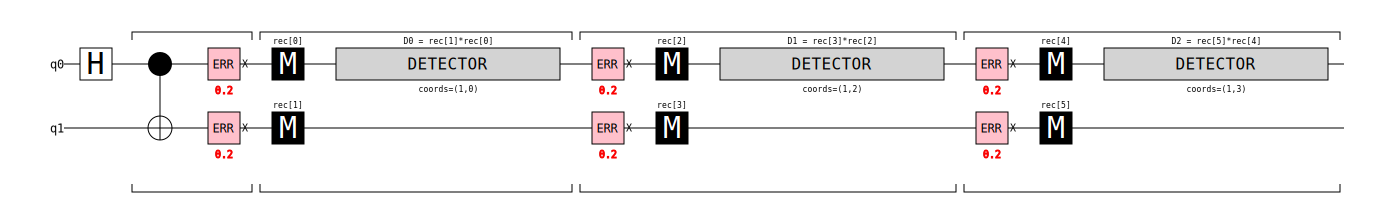

In [103]:
circuit.diagram('timeline-svg')

In [104]:
dem = circuit.detector_error_model()
dem.diagram('matchgraph-svg')

In [105]:
dem

stim.DetectorErrorModel('''
    error(0.32) D0 D1 D2
    error(0.32) D1 D2
    error(0.32) D2
    detector(1, 0) D0
    detector(1, 2) D1
    detector(1, 3) D2
''')

stim.Circuit('''
    R 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
    TICK
    DEPOLARIZE1(0.04) 0 2 4 6 8 10 12 14 16
    CX 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
    TICK
    CX 2 1 4 3 6 5 8 7 10 9 12 11 14 13 16 15
    TICK
    X_ERROR(0.01) 1 3 5 7 9 11 13 15
    MR 1 3 5 7 9 11 13 15
    DETECTOR(1, 0) rec[-8]
    DETECTOR(3, 0) rec[-7]
    DETECTOR(5, 0) rec[-6]
    DETECTOR(7, 0) rec[-5]
    DETECTOR(9, 0) rec[-4]
    DETECTOR(11, 0) rec[-3]
    DETECTOR(13, 0) rec[-2]
    DETECTOR(15, 0) rec[-1]
    REPEAT 24 {
        TICK
        DEPOLARIZE1(0.04) 0 2 4 6 8 10 12 14 16
        CX 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
        TICK
        CX 2 1 4 3 6 5 8 7 10 9 12 11 14 13 16 15
        TICK
        X_ERROR(0.01) 1 3 5 7 9 11 13 15
        MR 1 3 5 7 9 11 13 15
        SHIFT_COORDS(0, 1)
        DETECTOR(1, 0) rec[-8] rec[-16]
        DETECTOR(3, 0) rec[-7] rec[-15]
        DETECTOR(5, 0) rec[-6] rec[-14]
        DETECTOR(7, 0) rec[-5] rec[-13]
        DETECTOR(9, 0) rec[-4] r

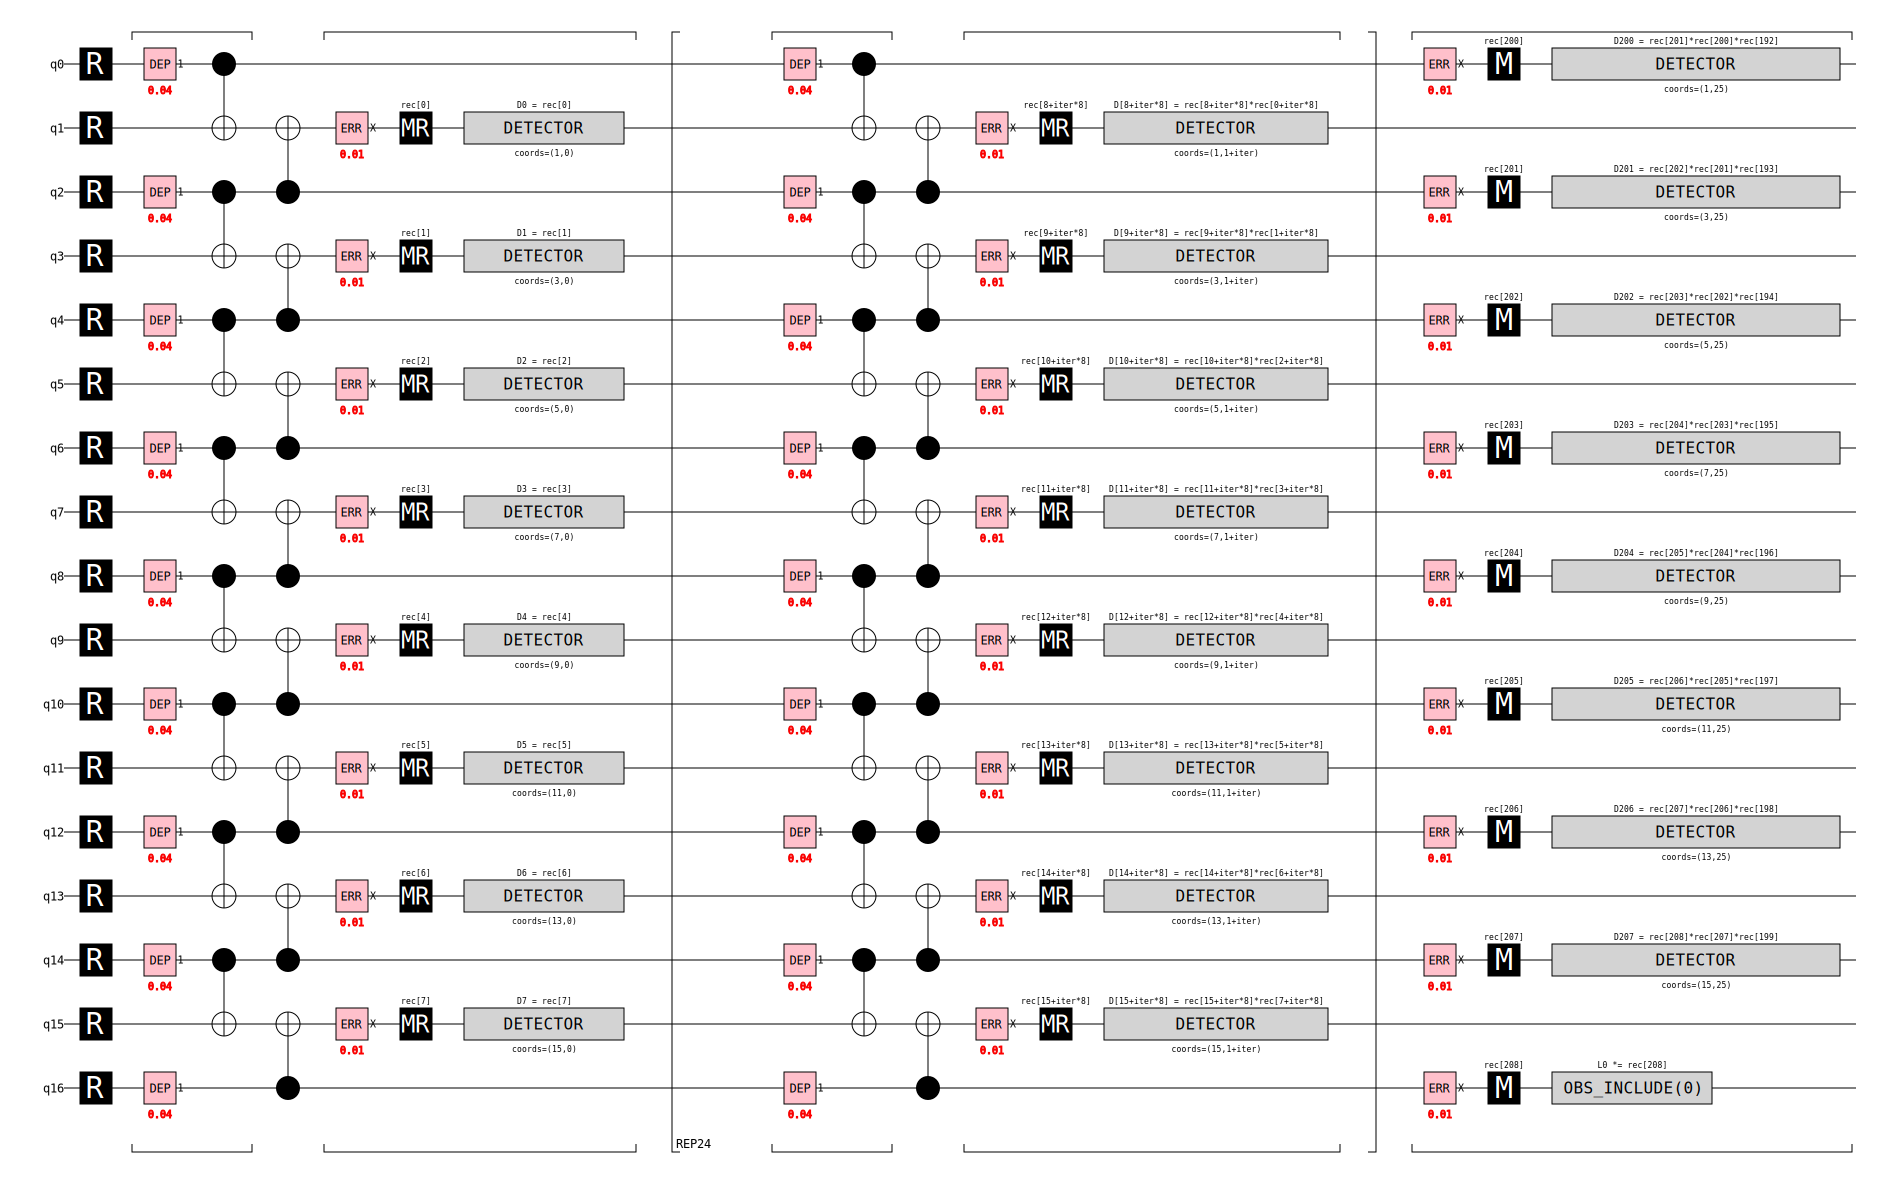

In [9]:
circuit = stim.Circuit.generated(
    "repetition_code:memory",
    rounds=25,
    distance=9,
    before_round_data_depolarization=0.04,
    before_measure_flip_probability=0.01)

print(repr(circuit))
circuit.diagram('timeline-svg')

In [10]:
sampler = circuit.compile_sampler()
one_sample = sampler.sample(shots=1)[0]
for k in range(0, len(one_sample), 8):
    timeslice = one_sample[k:k+8]
    print("".join("1" if e else "_" for e in timeslice))

_11_____
_11_____
_11_____
_11_____
_11_____
_11_____
_11_____
_11_____
_11_____
_1_1____
_1_1____
_1_1____
_1_1____
_1_1____
_1_1____
_1_1_11_
_1_1_11_
_1_1_11_
_1_1_11_
_1_1_1_1
_1_1_1_1
_1_1_1_1
_1_11__1
_1_1_1_1
_1_1_1_1
__11__11
_


In [11]:
detector_sampler = circuit.compile_detector_sampler()
one_sample = detector_sampler.sample(shots=1)[0]
for k in range(0, len(one_sample), 8):
    timeslice = one_sample[k:k+8]
    print("".join("!" if e else "_" for e in timeslice))

________
________
____!!__
!!!____!
____!!_!
________
________
_!!_____
________
!!______
___!!___
________
________
________
________
!_______
________
________
________
________
!!______
________
________
________
________
________


In [12]:
dem = circuit.detector_error_model()
print(repr(dem))

stim.DetectorErrorModel('''
    error(0.0266667) D0
    error(0.0266667) D0 D1
    error(0.01) D0 D8
    error(0.0266667) D1 D2
    error(0.01) D1 D9
    error(0.0266667) D2 D3
    error(0.01) D2 D10
    error(0.0266667) D3 D4
    error(0.01) D3 D11
    error(0.0266667) D4 D5
    error(0.01) D4 D12
    error(0.0266667) D5 D6
    error(0.01) D5 D13
    error(0.0266667) D6 D7
    error(0.01) D6 D14
    error(0.01) D7 D15
    error(0.0266667) D7 L0
    detector(1, 0) D0
    detector(3, 0) D1
    detector(5, 0) D2
    detector(7, 0) D3
    detector(9, 0) D4
    detector(11, 0) D5
    detector(13, 0) D6
    detector(15, 0) D7
    repeat 23 {
        error(0.0266667) D8
        error(0.0266667) D8 D9
        error(0.01) D8 D16
        error(0.0266667) D9 D10
        error(0.01) D9 D17
        error(0.0266667) D10 D11
        error(0.01) D10 D18
        error(0.0266667) D11 D12
        error(0.01) D11 D19
        error(0.0266667) D12 D13
        error(0.01) D12 D20
        error(0.0266667) D1

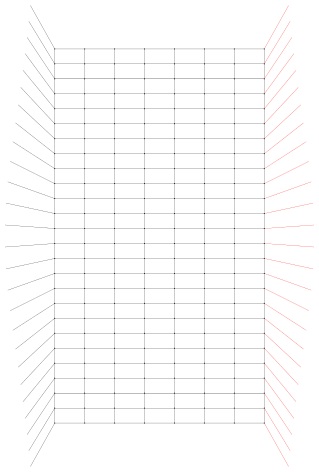

In [13]:
dem.diagram("matchgraph-svg")

In [14]:
import pymatching

In [15]:
def count_logical_errors(circuit: stim.Circuit, num_shots: int) -> int:
    # Sample the circuit.
    sampler = circuit.compile_detector_sampler()
    detection_events, observable_flips = sampler.sample(num_shots, separate_observables=True)

    # Configure a decoder using the circuit.
    detector_error_model = circuit.detector_error_model(decompose_errors=True)
    matcher = pymatching.Matching.from_detector_error_model(detector_error_model)

    # Run the decoder.
    predictions = matcher.decode_batch(detection_events)

    # Count the mistakes.
    num_errors = 0
    for shot in range(num_shots):
        actual_for_shot = observable_flips[shot]
        predicted_for_shot = predictions[shot]
        if not np.array_equal(actual_for_shot, predicted_for_shot):
            num_errors += 1
    return num_errors

In [16]:
circuit = stim.Circuit.generated("repetition_code:memory", rounds=100, distance=9, before_round_data_depolarization=0.01)
num_shots = 100_000
num_logical_errors = count_logical_errors(circuit, num_shots)
print("there were", num_logical_errors, "wrong predictions (logical errors) out of", num_shots, "shots")

there were 0 wrong predictions (logical errors) out of 100000 shots


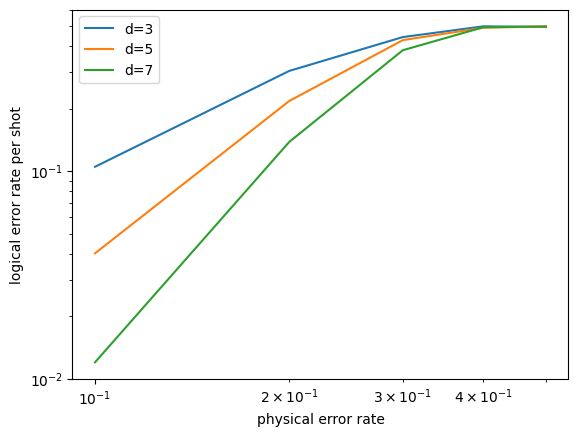

In [17]:
import matplotlib.pyplot as plt

num_shots = 10_000
for d in [3, 5, 7]:
    xs = []
    ys = []
    for noise in [0.1, 0.2, 0.3, 0.4, 0.5]:
        circuit = stim.Circuit.generated(
            "repetition_code:memory",
            rounds=d * 3,
            distance=d,
            before_round_data_depolarization=noise)
        num_errors_sampled = count_logical_errors(circuit, num_shots)
        xs.append(noise)
        ys.append(num_errors_sampled / num_shots)
    plt.plot(xs, ys, label="d=" + str(d))
plt.loglog()
plt.xlabel("physical error rate")
plt.ylabel("logical error rate per shot")
plt.legend()
plt.show()

In [18]:
!pip install sinter~=1.14
import sinter
from typing import List

  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'sinter' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'sinter'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for sinter: filename=sinter-1.16.0-py3-none-any.whl size=197605 sha256=ec9ccc9ea00738ce22b01dd53687a82cc8c03482b3f37558ba849ccf68dd2459
  Stored in directory: /Users/ygup3491/Library/Caches/pip/wheels/a6/8b/a6/a25b42416254e3066165c310de658e7476110c106dbc674160
Successfully built sinter


In [ ]:
tasks = [
    sinter.Task(
        circuit=stim.Circuit.generated(
            "repetition_code:memory",
            rounds=d * 3,
            distance=d,
            before_round_data_depolarization=noise,
        ),
        json_metadata={'d': d, 'p': noise},
    )
    for d in [3, 5, 7, 9]
    for noise in [0.05, 0.08, 0.1, 0.2, 0.3, 0.4, 0.5]
] 

collected_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=100_000,
    max_errors=500,
)

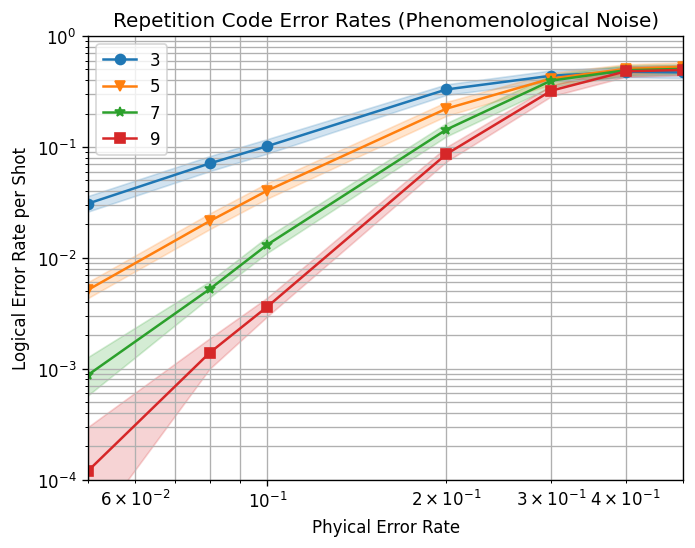

In [20]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
)
ax.set_ylim(1e-4, 1e-0)
ax.set_xlim(5e-2, 5e-1)
ax.loglog()
ax.set_title("Repetition Code Error Rates (Phenomenological Noise)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger